# Gene expression overlay

This notebook serves as an example for visualisation of gene expression from CPM embedding. For more details, please refer to Appendix G in our [paper](https://doi.org/10.1101/2025.08.22.671789).

We analyze scRNA-seq data from [Mantri et al. (2021)](#references), which includes transcriptomic profiles from 22,315 individual cells collected across four embryonic stages (days 4, 7, 10, and 14). This dataset contains gene expression profiles from cells spanning multiple lineages and provides a high-resolution view of how cellular differentiation and morphogenetic processes are coordinated during heart development, offering key insights into cardiac lineage specification. The trained model and the config files for CPM can be found [here](./results/chicken_cardiogenesis). We directly load the embedding for this example

In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import seaborn as sns
import random
import torch
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler

np.random.seed(25)

data_file = "./results/chicken_cardiogenesis/chicken_heart_cells_wo_scanorama_all_consol.csv"
embed_file = "./results/chicken_cardiogenesis/chicken_heart_cells_wo_scanorama_all_emb.csv"


embedding = pd.read_csv(embed_file, sep=',', header=None).to_numpy()
dataset = pd.read_csv(data_file, sep=',')

# shuffle the indices
idx = np.random.randint(0, len(dataset), size=len(dataset))
embedding = embedding[idx, :]
data = dataset.iloc[idx, :-2]

Next, we plot the gene expression overlaid on the embeddings for some genes of importance.

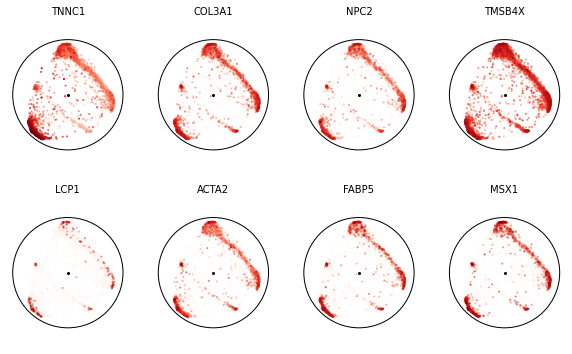

In [16]:
%matplotlib inline

# normalise the expression to make it comparable across different genes
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data.values)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns, index=data.index)

df = pd.DataFrame(embedding[:, :], columns=['cpm1', 'cpm2'])


genes = ["TNNC1", "COL3A1", "NPC2", "TMSB4X", "LCP1", "ACTA2", "FABP5", "MSX1"]
palette = sns.color_palette("Reds", as_cmap=True)


fig, axes = plt.subplots(
    nrows=2, ncols=4,
    figsize=(10, 3 * 2))

# flatten axes for easy iteration
axes = axes.flatten()

for i, gene in enumerate(genes):
    ax = axes[i]

    df[gene] = scaled_df[gene].values
    df = df.sort_values(by=gene)

    # add reference circle
    circle = plt.Circle((0, 0), radius=1, fc='none', color='black')
    ax.add_patch(circle)
    ax.plot(0, 0, '.', c=(0, 0, 0), ms=4)

    sns.scatterplot(
        x="cpm1", y="cpm2", hue=gene,
        palette=palette,
        alpha=0.5, edgecolor="none",
        data=df, ax=ax, s=4, legend=False)

    ax.set_title(gene, fontsize=10)
    ax.axis("off")
    ax.axis("equal")

<a id="references"></a>

## References

1. Madhav Mantri, Gaetano J Scuderi, Roozbeh Abedini-Nassab, Michael FZ Wang, David McKellar, Hao Shi, Benjamin Grodner, Jonathan T Butcher, and Iwijn De Vlaminck. Spatiotemporal single-cell rna sequencing of developing chicken hearts identifies interplay between cellular
differentiation and morphogenesis. Nature communications, 12(1):1771, 2021.